In [1]:
from sys import path
from pathlib import Path

import numpy  as np
import pandas as pd
import tables as tb
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from jupyfun import progressbar
from jupyfun import bin_centers

%matplotlib inline
auto_plot_style()

path.append("../analysis")

from utils import *

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
folder    = Path("/home/gonzalo/data/COLINA/mc/pcolina/light_tables/20260311/")
folder_s1 = folder / "s1_img"
folder_s2 = folder / "s2_img"

outputfile = folder / "light_tables.h5"
str(outputfile)

'/home/gonzalo/data/COLINA/mc/pcolina/light_tables/20260311/light_tables_new.h5'

In [4]:
def empty_s1_map(nbins, sensor_ids):
    xybin = np.arange(nbins)
    zbin, xbin, ybin, sensor_id = map(np.ravel, np.meshgrid(xybin, xybin, xybin, sensor_ids, indexing="ij"))
    return pd.DataFrame(dict(xbin=xbin, ybin=ybin, zbin=zbin, sensor_id=sensor_id, nevt=0, prob=0.0))

def empty_s2_map(nbins, sensor_ids):
    xybin = np.arange(nbins)
    xbin, ybin, sensor_id = map(np.ravel, np.meshgrid(xybin, xybin, sensor_ids, indexing="ij"))
    return pd.DataFrame(dict(xbin=xbin, ybin=ybin, sensor_id=sensor_id, nevt=0, prob=0.0))

def expand_imgs(row, sensor_ids):
    probs = np.concatenate([ row.prob_np.values[0].flatten()
                           , row.prob_fp.values[0].flatten()
                           ])
    probs = dict( nevt = row.nevt.values[0]
                , prob = probs)
    return pd.DataFrame(probs, index=sensor_ids)

# S1

In [5]:
filenames  = sorted(folder_s1.glob("*h5"))
len(filenames)

140

In [23]:
conf       = simconfig(filenames[0])
nphot      = conf.nparticles
zmax       = conf.drift_length # mm
rmax       = conf.el_diam/2 + conf.form_factor * zmax  # mm
nbins      = 100
xybins     = np.linspace(-rmax, rmax, nbins+1)
zbins      = np.linspace(0, zmax, nbins+1) + conf.neck_length
xybinsize  = np.diff(xybins)[0]
zbinsize   = np.diff( zbins)[0]
xycenters  = bin_centers(xybins)
zcenters   = bin_centers( zbins)
sensor_ids = pd.concat([ empty_sensor_df(conf.n_sipm_side, "np")
                       , empty_sensor_df(conf.n_sipm_side, "fp")
                       ]).index.to_series()
meta_s1       = pd.Series(dict(
    nphot     = nphot,
    zmax      = zmax,
    rmax      = rmax,
    nbins     =  nbins,
    xybins    = xybins,
    zbins     =  zbins,
    xybinsize = xybinsize,
     zbinsize =  zbinsize,
    xycenters = xycenters,
     zcenters =  zcenters,
), name="meta_s1")

In [7]:
data = []
for filename in progressbar(filenames):
    imgs = pd.read_hdf(filename)
    imgs.insert(0, "nevt", 1)
    imgs.insert(0, "ybin", np.clip(np.digitize(imgs.y0, xybins)-1, 0, nbins-1))
    imgs.insert(0, "xbin", np.clip(np.digitize(imgs.x0, xybins)-1, 0, nbins-1))
    imgs.insert(0, "zbin", np.clip(np.digitize(imgs.z0,  zbins)-1, 0, nbins-1))
    imgs.reset_index(inplace=True)
    imgs.drop(columns="event x0 y0 r0 z0".split(), inplace=True)
    data.append(imgs)
data_s1 = pd.concat(data, ignore_index=True)

Item 140 of 140 | 0.63 s/item | ETA 0.0 min | Ellapsed 1.5 min


In [8]:
data_s1

,zbin,xbin,ybin,nevt,image_np,image_fp
0,8,50,51,1,"[[[4, 4, 3, 5, 5], [5, 6, 7, 5, 2], [4, 13, 12...","[[[3, 1, 1, 0, 2, 2, 7, 5, 3, 2], [3, 3, 4, 3,..."
1,31,53,35,1,"[[[0, 2, 1, 0, 0], [2, 1, 3, 0, 2], [1, 0, 1, ...","[[[3, 1, 5, 3, 3, 6, 5, 7, 5, 1], [4, 1, 2, 2,..."
2,45,46,37,1,"[[[1, 2, 3, 1, 1], [0, 1, 1, 1, 3], [1, 2, 0, ...","[[[5, 6, 3, 4, 5, 3, 8, 2, 7, 2], [2, 4, 4, 3,..."
3,49,45,35,1,"[[[0, 0, 0, 0, 1], [2, 0, 0, 3, 5], [2, 1, 4, ...","[[[9, 2, 1, 3, 3, 8, 3, 5, 2, 3], [3, 8, 3, 6,..."
4,95,29,12,1,"[[[1, 0, 0, 3, 0], [0, 1, 0, 1, 0], [0, 1, 1, ...","[[[1, 1, 2, 2, 1, 3, 1, 0, 0, 0], [0, 2, 4, 1,..."
...,...,...,...,...,...,...
6999995,81,46,42,1,"[[[0, 0, 2, 0, 0], [0, 2, 1, 1, 2], [0, 0, 2, ...","[[[10, 15, 20, 12, 7, 15, 10, 21, 15, 9], [6, ..."
6999996,62,48,24,1,"[[[1, 0, 0, 0, 0], [0, 2, 1, 0, 3], [0, 0, 1, ...","[[[9, 1, 6, 6, 4, 0, 2, 3, 0, 3], [0, 0, 3, 1,..."
6999997,75,53,59,1,"[[[0, 2, 1, 0, 0], [0, 3, 2, 3, 0], [1, 0, 3, ...","[[[1, 0, 5, 4, 2, 2, 1, 1, 4, 3], [0, 4, 3, 0,..."
6999998,39,54,45,1,"[[[1, 1, 2, 1, 1], [2, 0, 3, 3, 3], [2, 2, 1, ...","[[[7, 4, 7, 5, 4, 1, 4, 2, 3, 5], [4, 7, 2, 2,..."


In [9]:
data = data_s1

lt = (data.groupby("zbin xbin ybin".split())
          .sum()
          .assign( prob_np = lambda df: df.image_np/df.nevt/nphot
                 , prob_fp = lambda df: df.image_fp/df.nevt/nphot
                 )
          .drop(columns="image_np image_fp".split())
          .groupby(level=(0,1,2))
          .apply(expand_imgs, sensor_ids)
          .reset_index()
     )

lt = (pd.concat([empty_s1_map(nbins, sensor_ids), lt], ignore_index=True)
        .groupby("sensor_id zbin xbin ybin".split())
        .last()
        .reset_index(level=(1,2,3))
     )

lt.insert(3, "y", (lt.ybin * xybinsize) + xycenters.min())
lt.insert(3, "x", (lt.xbin * xybinsize) + xycenters.min())
lt.insert(3, "z", (lt.zbin *  zbinsize) +  zcenters.min())
lt.drop  (columns="zbin xbin ybin".split(), inplace=True)
lt.reset_index(inplace=True)

s1_lt = lt

del lt
del data

s1_lt

,sensor_id,z,x,y,nevt,prob
0,0,10.6,-134.64,-134.64,0,0.0
1,0,10.6,-134.64,-131.92,0,0.0
2,0,10.6,-134.64,-129.20,0,0.0
3,0,10.6,-134.64,-126.48,0,0.0
4,0,10.6,-134.64,-123.76,0,0.0
...,...,...,...,...,...,...
124999995,4024,129.4,134.64,123.76,0,0.0
124999996,4024,129.4,134.64,126.48,0,0.0
124999997,4024,129.4,134.64,129.20,0,0.0
124999998,4024,129.4,134.64,131.92,0,0.0


In [10]:
s1_lt.sensor_id.unique()

array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
         22,   23,   24, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007,
       1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018,
       1019, 1020, 1021, 1022, 1023, 1024, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 3000, 3001,
       3002, 3003, 3004, 3005, 3006, 3007, 3008, 3009, 3010, 3011, 3012,
       3013, 3014, 3015, 3016, 3017, 3018, 3019, 3020, 3021, 3022, 3023,
       3024, 4000, 4001, 4002, 4003, 4004, 4005, 4006, 4007, 4008, 4009,
       4010, 4011, 4012, 4013, 4014, 4015, 4016, 4017, 4018, 4019, 4020,
       4021, 4022, 4023, 4024])

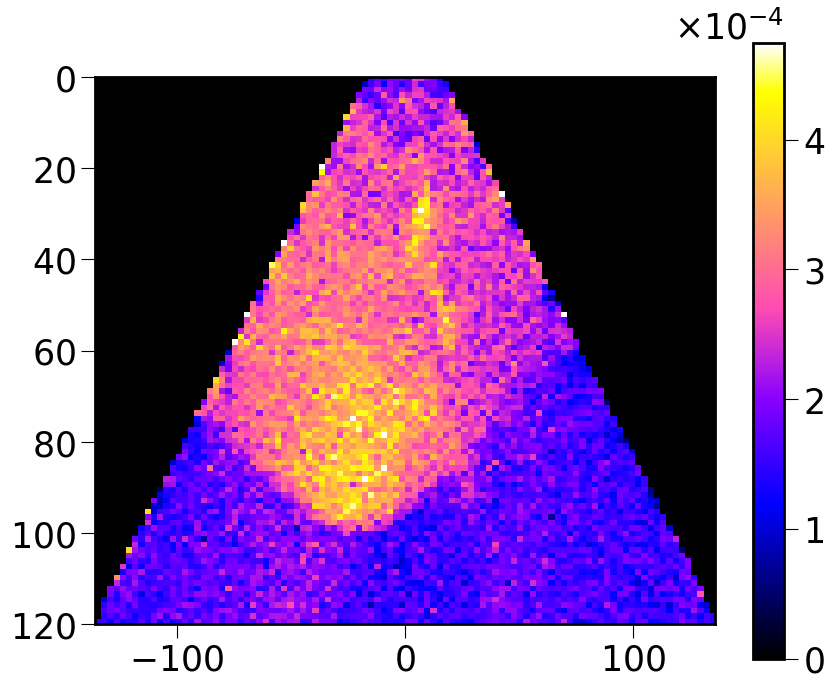

In [11]:
lt0 = s1_lt.loc[lambda df: df.sensor_id==1015].loc[lambda df: np.isclose(df.y, 6.8)]
img = lt0.prob.values
plt.imshow( img.reshape(nbins, nbins)
          , origin = "lower"
          , vmin   = 0
          , vmax   = np.percentile(img, 99.9)
          , extent = (-rmax, rmax, 0, zmax)
          , aspect = 2
          )

plt.gca().invert_yaxis()
plt.colorbar()

# S2

In [12]:
filenames  = sorted(folder_s2.glob("*h5"))
len(filenames)

100

In [22]:
conf       = simconfig(filenames[0])
nphot      = conf.nparticles
rmax       = conf.el_diam/2 + 1  # mm
nbins      = 200
xybins     = np.linspace(-rmax, rmax, nbins+1)
xybinsize  = np.diff(xybins)[0]
xycenters  = bin_centers(xybins)
sensor_ids = pd.concat([ empty_sensor_df(conf.n_sipm_side, "np")
                       , empty_sensor_df(conf.n_sipm_side, "fp")
                       ]).index.to_series()

meta_s2       = pd.Series(dict(
    nphot     = nphot,
    rmax      = rmax,
    nbins     =  nbins,
    xybins    = xybins,
    xybinsize = xybinsize,
    xycenters = xycenters,
), name="meta_s2")

In [14]:
data = []
for filename in progressbar(filenames):
    imgs = pd.read_hdf(filename)
    imgs.insert(0, "nevt", 1)
    imgs.insert(0, "ybin", np.clip(np.digitize(imgs.y0, xybins)-1, 0, nbins-1))
    imgs.insert(0, "xbin", np.clip(np.digitize(imgs.x0, xybins)-1, 0, nbins-1))
    imgs.reset_index(inplace=True)
    imgs.drop(columns="event x0 y0 z0 r0".split(), inplace=True)
    data.append(imgs)
data = pd.concat(data, ignore_index=True)

Item 100 of 100 | 0.52 s/item | ETA 0.0 min | Ellapsed 0.9 min


In [15]:
data

,xbin,ybin,nevt,image_np,image_fp
0,181,144,1,"[[[3, 2, 1, 0, 1], [2, 6, 9, 2, 2], [2, 12, 15...","[[[0, 0, 1, 2, 0, 0, 1, 0, 2, 0], [2, 0, 0, 1,..."
1,60,63,1,"[[[21, 24, 17, 22, 7], [23, 34, 46, 14, 11], [...","[[[0, 0, 0, 1, 1, 1, 0, 0, 1, 1], [1, 0, 2, 1,..."
2,137,148,1,"[[[1, 2, 6, 1, 0], [1, 6, 4, 1, 2], [9, 17, 6,...","[[[2, 1, 0, 1, 1, 2, 1, 1, 0, 1], [1, 0, 0, 0,..."
3,33,71,1,"[[[27, 34, 35, 17, 4], [13, 23, 25, 16, 16], [...","[[[0, 1, 0, 0, 1, 1, 2, 1, 3, 2], [3, 1, 1, 0,..."
4,150,27,1,"[[[1, 5, 1, 2, 0], [6, 12, 10, 2, 0], [6, 7, 5...","[[[1, 0, 2, 0, 0, 2, 2, 0, 0, 1], [1, 1, 0, 0,..."
...,...,...,...,...,...
4999995,161,46,1,"[[[0, 7, 3, 1, 0], [11, 18, 9, 7, 1], [30, 13,...","[[[1, 0, 2, 0, 1, 0, 0, 1, 1, 1], [2, 2, 0, 1,..."
4999996,135,150,1,"[[[1, 2, 4, 3, 1], [1, 14, 17, 15, 14], [6, 9,...","[[[0, 1, 1, 2, 0, 0, 0, 0, 1, 1], [2, 2, 0, 1,..."
4999997,96,17,1,"[[[14, 14, 5, 4, 1], [35, 17, 14, 5, 0], [42, ...","[[[0, 0, 1, 1, 0, 3, 0, 2, 3, 1], [1, 0, 0, 1,..."
4999998,75,181,1,"[[[2, 2, 5, 13, 20], [1, 14, 14, 3, 19], [0, 8...","[[[0, 1, 0, 1, 0, 0, 0, 0, 0, 1], [1, 1, 0, 0,..."


In [16]:
lt = (data.groupby("xbin ybin".split())
          .sum()
          .assign( prob_np = lambda df: df.image_np/df.nevt/nphot
                 , prob_fp = lambda df: df.image_fp/df.nevt/nphot
                 )
          .drop(columns="image_np image_fp".split())
          .groupby(level=(0,1))
          .apply(expand_imgs, sensor_ids)
          .reset_index()
     )
lt = (pd.concat([empty_s2_map(nbins, sensor_ids), lt], ignore_index=True)
        .groupby("sensor_id xbin ybin".split())
        .last()
        .reset_index(level=(1,2))
     )
lt.insert(2, "y", (lt.ybin * xybinsize) + xycenters.min())
lt.insert(2, "x", (lt.xbin * xybinsize) + xycenters.min())
lt.drop(columns="xbin ybin".split(), inplace=True)
lt.reset_index(inplace=True)

s2_lt = lt

del lt
del data

s2_lt

,sensor_id,x,y,nevt,prob
0,0,-16.915,-16.915,0,0.0
1,0,-16.915,-16.745,0,0.0
2,0,-16.915,-16.575,0,0.0
3,0,-16.915,-16.405,0,0.0
4,0,-16.915,-16.235,0,0.0
...,...,...,...,...,...
4999995,4024,16.915,16.235,0,0.0
4999996,4024,16.915,16.405,0,0.0
4999997,4024,16.915,16.575,0,0.0
4999998,4024,16.915,16.745,0,0.0


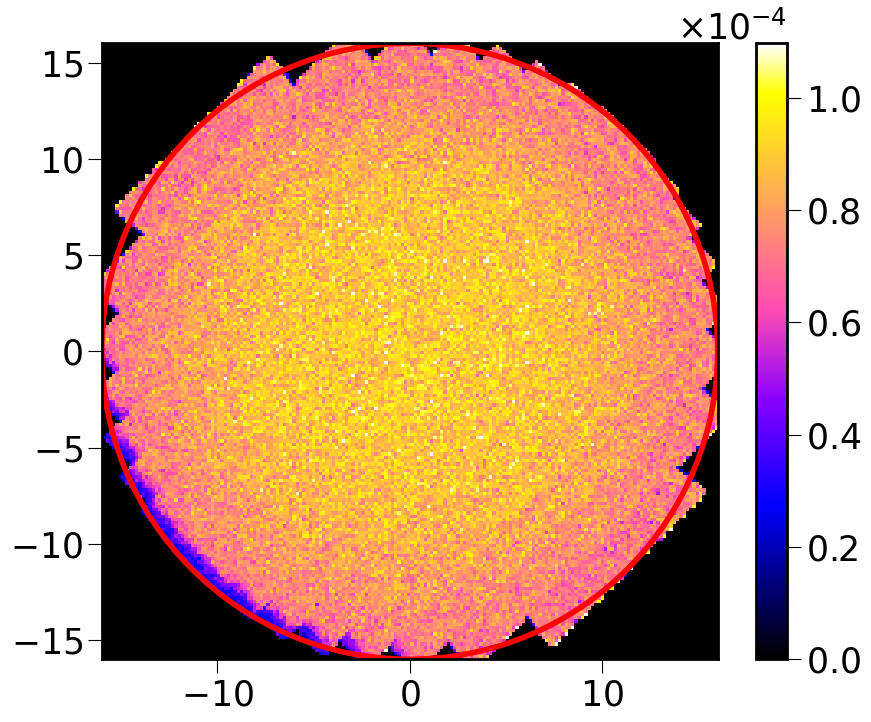

In [17]:
lt0 = s2_lt.loc[lambda df: df.sensor_id==1012]
img = lt0.prob.values
plt.imshow( img.reshape(nbins, nbins)
          , origin = "lower"
          , vmin   = 0
          , vmax   = np.percentile(img, 99.9)
          , extent = (-rmax, rmax, -rmax, rmax))

draw_el(plt.gca(), 16)
plt.colorbar()

In [18]:
class S1Table(tb.IsDescription):
    sensor_id = tb. UInt16Col(pos=0)
    z         = tb.Float32Col(pos=1)
    x         = tb.Float32Col(pos=2)
    y         = tb.Float32Col(pos=3)
    nevt      = tb. UInt32Col(pos=4)
    prob      = tb.Float32Col(pos=5)

class S2Table(tb.IsDescription):
    sensor_id = tb. UInt16Col(pos=0)
    x         = tb.Float32Col(pos=1)
    y         = tb.Float32Col(pos=2)
    nevt      = tb. UInt32Col(pos=3)
    prob      = tb.Float32Col(pos=4)

def store_table(outputfile, df, mode, which):
    description = S1Table if which=="S1" else S2Table
    with tb.open_file(outputfile, mode=mode, filters=tb.Filters(complib="zlib", complevel=4)) as file:
        group = file.create_group(file.root, which)
        table = file.create_table(group, "LT", description, title=f"{which} LT", expectedrows = len(df))

        columns = df.columns.tolist()
        row     = table.row
        for data in progressbar(df.itertuples(), nelements=len(df), flushmod=1000000):
            for name, value in zip(columns, data[1:]):
                row[name] = value
            row.append()
        table.flush()

In [27]:
store_table(outputfile, s1_lt, "w", "S1")
store_table(outputfile, s2_lt, "a", "S2")
meta_s1.to_hdf(outputfile, key="/S1/meta", mode="a", complib="zlib", complevel=4)
meta_s2.to_hdf(outputfile, key="/S2/meta", mode="a", complib="zlib", complevel=4)

Item 124000001 of 125000000 | 0.00 s/item | ETA 0.0 min | Ellapsed 2.7 min
Item 4000001 of 5000000 | 0.00 s/item | ETA 0.0 min | Ellapsed 0.1 min


/tmp/ipykernel_742240/1554645148.py:3: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  meta_s1.to_hdf(outputfile, key="/S1/meta", mode="a", complib="zlib", complevel=4)
/tmp/ipykernel_742240/1554645148.py:4: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  meta_s2.to_hdf(outputfile, key="/S2/meta", mode="a", complib="zlib", complevel=4)


In [28]:
!ptdump -v $outputfile

/ (RootGroup) ''
/S1 (Group) ''
/S1/LT (Table(125000000,)shuffle, zlib(4)) 'S1 LT'
  description := {
  "sensor_id": UInt16Col(shape=(), dflt=0, pos=0),
  "z": Float32Col(shape=(), dflt=0.0, pos=1),
  "x": Float32Col(shape=(), dflt=0.0, pos=2),
  "y": Float32Col(shape=(), dflt=0.0, pos=3),
  "nevt": UInt32Col(shape=(), dflt=0, pos=4),
  "prob": Float32Col(shape=(), dflt=0.0, pos=5)}
  byteorder := 'little'
  chunkshape := (23831,)
/S2 (Group) ''
/S2/LT (Table(5000000,)shuffle, zlib(4)) 'S2 LT'
  description := {
  "sensor_id": UInt16Col(shape=(), dflt=0, pos=0),
  "x": Float32Col(shape=(), dflt=0.0, pos=1),
  "y": Float32Col(shape=(), dflt=0.0, pos=2),
  "nevt": UInt32Col(shape=(), dflt=0, pos=3),
  "prob": Float32Col(shape=(), dflt=0.0, pos=4)}
  byteorder := 'little'
  chunkshape := (7281,)
/S2/meta (Group) ''
/S2/meta/index (CArray(6,)shuffle, zlib(4)) ''
  atom := StringAtom(itemsize=9, shape=(), dflt=b'')
  maindim := 0
  flavor := 'numpy'
  byteorder := 'irrelevant'
  chunkshape 

In [29]:
!ls -lh $outputfile

-rw-rw-r-- 1 gonzalo gonzalo 186M Apr  2 14:06 /home/gonzalo/data/COLINA/mc/pcolina/light_tables/20260311/light_tables_new.h5
